In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import MinMaxScaler

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Dropout
from keras.optimizers import Adam

In [64]:
df = pd.read_csv('c:\\Users\\DELL\\OneDrive\\Desktop\\Documents\\dataaaa\\AAPL_featuress.csv',parse_dates=['date'])

In [65]:
#Loaded last year's stock data for Apple Inc. (AAPL) from Yahoo Finance, including features like Open, High, Low, Close, Volume.
from datetime import datetime, timedelta
end_date = datetime.now()
start_date = end_date - timedelta(days=365) # Simple one-year calculation

# Filter the DataFrame using boolean conditions
# The '&' operator combines conditions (use parentheses for clarity)
df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

In [14]:
import os
import pandas as pd
import time

file_path = "dataaaa/AAPL_featuress.csv"

# 1. Force close/delete to break any locks
if os.path.exists(file_path):
    os.remove(file_path)
    time.sleep(1) # Brief pause for OneDrive/Windows to catch up

# 2. Save the fresh data
df.to_csv(file_path, index=False)
print(f"Verified Write: {os.path.getsize(file_path)} bytes saved.")

Verified Write: 23933 bytes saved.


In [6]:
df.head()

,date,open,high,low,close,volume
2276,2025-03-10 13:30:00,235.539993,236.160004,224.220001,227.479996,72071200
2277,2025-03-11 13:30:00,223.809998,225.839996,217.449997,220.839996,76137400
2278,2025-03-12 13:30:00,220.139999,221.750000,214.910004,216.979996,62547500
2279,2025-03-13 13:30:00,215.949997,216.839996,208.419998,209.679993,61368300
2280,2025-03-14 13:30:00,211.250000,213.949997,209.580002,213.490005,60107600


In [66]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['close']])

In [67]:
df_final = df[['close']]
split_idx = (0.8*(int(len(df))))
train_data = scaled_data[:int(split_idx)]
test_data = scaled_data[int(split_idx):]

In [68]:
test_data

array([[0.93486856],
       [0.92827632],
       [0.93047373],
       [0.89382072],
       [0.89821555],
       [0.87386828],
       [0.87694472],
       [0.88995352],
       [0.86622132],
       [0.87843881],
       [0.89118393],
       [0.88758013],
       [0.89074455],
       [0.88476738],
       [0.87404398],
       [0.86657298],
       [0.83361174],
       [0.79054218],
       [0.77269917],
       [0.7613607 ],
       [0.76426117],
       [0.77199612],
       [0.77902774],
       [0.76944704],
       [0.75406513],
       [0.7305089 ],
       [0.65289616],
       [0.66124631],
       [0.66739918],
       [0.66467428],
       [0.72945418],
       [0.75459249],
       [0.73850752],
       [0.75468047],
       [0.76522818],
       [0.85778332],
       [0.85312481],
       [0.91474016],
       [0.90964227],
       [0.92906736],
       [0.89830353],
       [0.89004123],
       [0.90603848],
       [0.78500492],
       [0.73270632],
       [0.80390264],
       [0.80803379],
       [0.774

In [69]:
train_data.shape,test_data.shape

((190, 1), (48, 1))

In [70]:
def create_sequences(data,n_steps):
    X, y = [],[]
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X),np.array(y)

In [71]:
n_steps = 30
X_train,y_train = create_sequences(train_data,n_steps)
X_test,y_test = create_sequences(test_data,n_steps)

In [72]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((160, 30, 1), (160, 1), (18, 30, 1), (18, 1))

In [73]:
tf.keras.backend.set_floatx('float32')  # CPU = float32 like GPU
X_train = X_train.astype(np.float32)
y_train = y_train.astype(np.float32)

In [74]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Dropout
from keras.optimizers import Adam

In [82]:
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(30, 1)),  # Tomorrow only!
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)  # Single price!
])

# Volatility-aware optimizer
opt= Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999,epsilon=1e-07)
model.compile(optimizer=opt, loss='mse')
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100, verbose=1)

Epoch 1/100


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - loss: 0.2842 - val_loss: 0.3769
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1316 - val_loss: 0.1294
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0294 - val_loss: 0.0164
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0334 - val_loss: 0.0078
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0126 - val_loss: 0.0282
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0201 - val_loss: 0.0366
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0190 - val_loss: 0.0159
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0162 - val_loss: 0.0055
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0119 - val_loss: 0.0055
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0139 - val_loss: 0.0072
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0139 - val_loss: 0.0085
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0120 - val_loss: 0.006

In [76]:

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,029 (222.77 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,020 (148.52 KB)

In [83]:
n_steps = 30 
n_future = 30
current_input = df['close'].tail(n_steps).values 
current_input = scaler.transform(current_input.reshape(-1,1)) 
predictions = [] 
for i in range(n_future): 
    X = current_input.reshape(1, n_steps, 1) 
    yhat = model.predict(X, verbose=0) 
    predictions.append(yhat[0,0]) 
    current_input = np.append(current_input[1:], yhat) 
predictions_real = scaler.inverse_transform( np.array(predictions).reshape(-1,1) )

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [84]:
print(predictions_real)

[[267.62784]
 [268.16394]
 [268.76657]
 [269.40622]
 [270.06317]
 [270.72467]
 [271.3844 ]
 [272.03806]
 [272.684  ]
 [273.3275 ]
 [273.95892]
 [274.5789 ]
 [275.1893 ]
 [275.7833 ]
 [276.3662 ]
 [276.9436 ]
 [277.5128 ]
 [278.0751 ]
 [278.6221 ]
 [279.16486]
 [279.69656]
 [280.22485]
 [280.74734]
 [281.26974]
 [281.7898 ]
 [282.30508]
 [282.83035]
 [283.35855]
 [283.8765 ]
 [284.39096]]


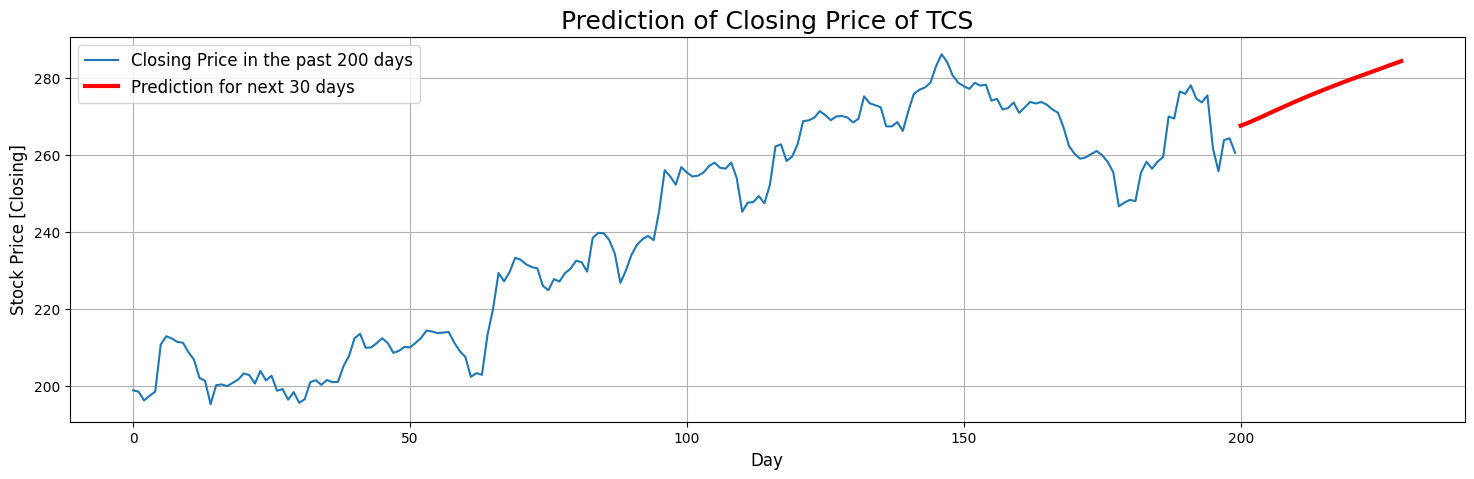

In [85]:
days=np.arange(0,200)
day_pred=np.arange(200,230)
plt.figure(figsize=(18,5))
plt.plot(days,df.close.tail(200), label = 'Closing Price in the past 200 days')
plt.plot(day_pred,predictions_real, color = 'red', label = 'Prediction for next 30 days', lw = 3)
plt.legend(fontsize = 12)
plt.title('Prediction of Closing Price of TCS', fontsize = 18)
plt.xlabel('Day' ,fontsize = 12)
plt.ylabel('Stock Price [Closing]' ,fontsize = 12)
plt.grid()
plt.show()

In [86]:
y_pred = model.predict(X_test)

# Inverse transform (only Close column matters for eval)

y_test_full = y_test
y_pred_full = y_pred.flatten()
y_test_full = y_test_full.reshape(-1, 1)
y_pred_full = y_pred_full.reshape(-1, 1)

y_test_inv = scaler.inverse_transform(y_test_full)
y_pred_inv = scaler.inverse_transform(y_pred_full)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
RMSE: 7.48, MAE: 5.67


In [87]:
y_pred_inv[0:5], y_test_inv[0:5]

(array([[256.76392],
        [257.198  ],
        [258.1523 ],
        [258.60733],
        [259.3219 ]], dtype=float32),
 array([[255.41000366],
        [258.26998901],
        [256.44000244],
        [258.27999878],
        [259.48001099]]))